# 06 Ensemble Member Inference (All Methods)
Run 5 selected members from **each** of the 4 UQ ensembles through the saved
RF bloom classifier. For each ensemble, display 5 per-member confusion matrices
directly after the inference call. At the end, compare methods via a single
mean ± std confusion matrix.

In [1]:
# ── USER CONFIGURATION ────────────────────────────────────────────────────────
# Member indices applied to EVERY ensemble (bootstrap, glue, enkf).
MEMBER_INDICES = [0, 40, 80, 120, 160]

METHODS = ["bootstrap", "glue", "enkf"]

SAVE_OUTPUTS = True
TEST_CUTOFF  = "2019-01-01"
# ─────────────────────────────────────────────────────────────────────────────

assert len(MEMBER_INDICES) == 5,            "This notebook expects exactly 5 members."
assert all(0 <= i < 200 for i in MEMBER_INDICES), "Member indices must be in 0-199."
assert all(m in ("bootstrap", "glue", "enkf") for m in METHODS)

print(f"Config OK: methods={METHODS}, members={MEMBER_INDICES}")

Config OK: methods=['bootstrap', 'glue', 'enkf'], members=[0, 40, 80, 120, 160]


In [2]:
import sys
if "src" not in sys.path:
    sys.path.insert(0, "src")

from pathlib import Path
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.patches as mpatches
import seaborn as sns
import joblib
from sklearn.metrics import (
    balanced_accuracy_score, precision_score, recall_score, f1_score,
    confusion_matrix, precision_recall_curve, average_precision_score,
)
from red_tide_reanalysis.ml import resample_ensemble, build_features, run_inference
from red_tide_reanalysis.ml.feature_builder import FEATURE_COLS, M3S_TO_CFS

# ── Paths (repo-root-relative; launch Jupyter from repo root) ────────────────
OBS_CSV      = Path("machineLearning/machineLearning/input/data_weekly_intepolated.csv")
ENSEMBLE_DIR = Path("output/ensembles")
MODEL_PATH   = Path("models/rf_bloom_classifier.joblib")
SCALER_PATH  = Path("models/robust_scaler.joblib")
OUTPUT_DIR   = Path("output/ml")
OUTPUT_DIR.mkdir(parents=True, exist_ok=True)
FIGURES_DIR  = OUTPUT_DIR / "figures"

ENSEMBLE_FILES = {
    "bootstrap": "bootstrap_02296750_peace_river_total_nitrogen_members.csv",
    "glue":      "glue_02296750_peace_river_total_nitrogen_members.csv",
    "enkf":      "enkf_02296750_peace_river_total_nitrogen_members.csv",
}

assert MODEL_PATH.exists(),  f"Model not found: {MODEL_PATH} — run 00_serialize_model.ipynb first"
assert SCALER_PATH.exists(), f"Scaler not found: {SCALER_PATH}"
if SAVE_OUTPUTS:
    FIGURES_DIR.mkdir(parents=True, exist_ok=True)

METHOD_COLORS = {
    "bootstrap": "steelblue",
    "glue":      "darkorange",
    "enkf":      "forestgreen",
}

selected_cols = [f"member_{i:04d}" for i in MEMBER_INDICES]

# Dicts populated as each method is run
proba_by_method = {}
pred_by_method  = {}


def plot_member_cms(method_name):
    """Plot 5 confusion matrices side-by-side for the 5 selected members
    of `method_name`. Uses test-period predictions only."""
    pred  = pred_by_method[method_name]
    fig, axes = plt.subplots(1, 5, figsize=(20, 4.2))
    for j, (col, ax) in enumerate(zip(selected_cols, axes)):
        y_pred_j = pred[j][test_mask_members]
        cm       = confusion_matrix(y_test_members, y_pred_j, labels=[0, 1])
        bal_acc  = balanced_accuracy_score(y_test_members, y_pred_j)
        sns.heatmap(cm, annot=True, fmt="d", cmap="Blues", ax=ax, cbar=False,
                    xticklabels=["No Bloom", "Bloom"],
                    yticklabels=["No Bloom", "Bloom"])
        ax.set_xlabel("Predicted")
        ax.set_ylabel("Actual" if j == 0 else "")
        ax.set_title(f"{col}\nBal. Acc = {bal_acc:.3f}")

    fig.suptitle(
        f"{method_name.upper()} — Per-Member Confusion Matrices (Test Period 2019+)",
        fontsize=13,
    )
    plt.tight_layout()

    if SAVE_OUTPUTS:
        fname = FIGURES_DIR / f"{method_name}_member_cms.png"
        plt.savefig(fname, dpi=150, bbox_inches="tight")
        print(f"Saved: {fname}")
    plt.show()


print("Setup OK")

Setup OK


## Step 1 — Resample all ensembles and select members

In [3]:
weekly_selected_by_method = {}

for method in METHODS:
    ens_csv = ENSEMBLE_DIR / ENSEMBLE_FILES[method]
    weekly_full = resample_ensemble(ens_csv)               # (T_weeks, 200), mg/L

    # TN ensembles are sparse (emitted at observation dates only, ~787 daily
    # records → 695/1249 non-NaN weekly rows per member). The obs `peace_TN`
    # column is already weekly-interpolated; we must mirror that on the ensemble
    # side so lag features don't cascade NaN and shrink the ML test window.
    # Time-linear interpolate between observations, then front/back-fill edges.
    weekly_full = weekly_full.interpolate(method="time", limit_direction="both")

    weekly_selected_by_method[method] = weekly_full[selected_cols].copy()
    print(f"  {method}: {weekly_full.shape[0]} weekly rows  "
          f"({weekly_full.index[0].date()} → {weekly_full.index[-1].date()})  "
          f"NaN after interp: {int(weekly_full.isna().sum().sum())}")

print(f"\nSelected members (applied to each method): {selected_cols}")


  bootstrap: 1249 weekly rows  (2000-01-03 → 2023-12-04)  NaN after interp: 0
  glue: 1249 weekly rows  (2000-01-03 → 2023-12-04)  NaN after interp: 0
  enkf: 1249 weekly rows  (2000-01-03 → 2023-12-04)  NaN after interp: 0

Selected members (applied to each method): ['member_0000', 'member_0040', 'member_0080', 'member_0120', 'member_0160']


## Step 2 — Build features, baseline, and test-period masks

All 4 methods share the same weekly grid, so the aligned date index and
true bloom labels are computed once here.

In [4]:
# ── Ensemble features per method (TN path) ──────────────────────────────────
features_by_method = {}
for method in METHODS:
    features_by_method[method] = build_features(
        weekly_selected_by_method[method], OBS_CSV, member_role="peace_TN"
    )

# ── Aligned DatetimeIndex (must mirror build_features' internal dropna) ──────
# build_features with member_role="peace_TN" drops obs peace_TN, inner-joins the
# member as peace_TN, then adds 6 lag/rolling features (kb_prev1, kb_prev2,
# peace_discharge_prev1, peace_TN_prev1, peace_TP_prev1, discharge_4w_avg) and
# dropna. We replicate that exactly here so y_true aligns to the feature axis.
obs_no_tn  = pd.read_csv(OBS_CSV, parse_dates=["time"], index_col="time").drop(columns=["peace_TN"])
member0_tn = weekly_selected_by_method[METHODS[0]].iloc[:, 0].rename("peace_TN")
merged0    = obs_no_tn.join(member0_tn, how="inner")
merged0["kb_prev1"]              = merged0["kb"].shift(1)
merged0["kb_prev2"]              = merged0["kb"].shift(2)
merged0["peace_discharge_prev1"] = merged0["peace_discharge"].shift(1)
merged0["peace_TN_prev1"]        = merged0["peace_TN"].shift(1)
merged0["peace_TP_prev1"]        = merged0["peace_TP"].shift(1)
merged0["discharge_4w_avg"]      = merged0["peace_discharge"].rolling(window=4).mean()
aligned_index = merged0.dropna().index

# Sanity: notebook-side alignment must match build_features' T axis exactly.
for method in METHODS:
    assert features_by_method[method].shape[1] == len(aligned_index), (
        f"alignment drift for {method}: features T={features_by_method[method].shape[1]} "
        f"vs aligned_index={len(aligned_index)}"
    )

# ── True labels ──────────────────────────────────────────────────────────────
obs_full = pd.read_csv(OBS_CSV, parse_dates=["time"], index_col="time")
obs_full["bloom"]            = (obs_full["kb"] >= 100_000).astype(int)
obs_full["target_next_week"] = obs_full["bloom"].shift(-1)
y_true_series = obs_full.loc[aligned_index, "target_next_week"]

# shift(-1) leaves NaN on last row — trim index and features
valid_mask    = y_true_series.notna().values
aligned_index = aligned_index[valid_mask]
for method in METHODS:
    features_by_method[method] = features_by_method[method][:, valid_mask, :]
y_true = y_true_series.dropna().astype(int)

# ── Test-period mask (aligned to ensemble index) ─────────────────────────────
test_mask_members  = aligned_index  >= TEST_CUTOFF
y_test_members     = y_true[test_mask_members].values

print(f"Features aligned to shape ({len(MEMBER_INDICES)}, {len(aligned_index)}, {len(FEATURE_COLS)}) per method")
print(f"Aligned dates: {aligned_index[0].date()} → {aligned_index[-1].date()}")
print(f"Test period: {test_mask_members.sum()} weeks")
print(f"Bloom weeks — test (members): {int(y_test_members.sum())}")


Features aligned to shape (5, 1246, 15) per method
Aligned dates: 2000-01-24 → 2023-12-04
Test period: 257 weeks
Bloom weeks — test (members): 80


In [5]:
# ── Obs-TN baseline (D-13): observed peace_TN treated as 1-member "ensemble"
# so it flows through the identical build_features + run_inference pipeline.
# The baseline uses the same weekly Monday-anchored grid as the real ensembles,
# but its post-dropna T axis differs (obs peace_TN is densely interpolated while
# ensemble members have NaN weeks outside their data range). We intersect to
# aligned_index after feature build.
weekly_grid = weekly_selected_by_method[METHODS[0]].index  # W-MON anchored, len=1249
obs_full_baseline = pd.read_csv(OBS_CSV, parse_dates=["time"], index_col="time")
obs_tn_weekly = obs_full_baseline["peace_TN"].reindex(weekly_grid)
obs_tn_ensemble = obs_tn_weekly.to_frame("member_0000")
features_baseline = build_features(obs_tn_ensemble, OBS_CSV, member_role="peace_TN")
# features_baseline shape: (1, T_baseline, 15). Replicate build_features' internal
# alignment to get the per-row date index, then intersect to aligned_index.
_obs_no_tn = pd.read_csv(OBS_CSV, parse_dates=["time"], index_col="time").drop(columns=["peace_TN"])
_merged = _obs_no_tn.join(obs_tn_weekly.rename("peace_TN"), how="inner")
_merged["kb_prev1"]              = _merged["kb"].shift(1)
_merged["kb_prev2"]              = _merged["kb"].shift(2)
_merged["peace_discharge_prev1"] = _merged["peace_discharge"].shift(1)
_merged["peace_TN_prev1"]        = _merged["peace_TN"].shift(1)
_merged["peace_TP_prev1"]        = _merged["peace_TP"].shift(1)
_merged["discharge_4w_avg"]      = _merged["peace_discharge"].rolling(window=4).mean()
baseline_feature_index = _merged.dropna().index
assert features_baseline.shape[1] == len(baseline_feature_index), (
    f"baseline replica drift: features T={features_baseline.shape[1]} vs "
    f"replica index={len(baseline_feature_index)}"
)

# Trim baseline to the same aligned_index the ensemble features use.
baseline_sel = baseline_feature_index.isin(aligned_index)
features_baseline = features_baseline[:, baseline_sel, :]
assert features_baseline.shape[1] == len(aligned_index), (
    f"baseline T={features_baseline.shape[1]} vs aligned_index={len(aligned_index)} — "
    f"ensemble aligned_index is not a subset of baseline_feature_index"
)

proba_baseline = run_inference(features_baseline, MODEL_PATH, SCALER_PATH)[0]  # shape (T,)
baseline_dates = aligned_index  # same alignment as ensemble methods

# Back-compat aliases for downstream cells that were written against flat-obs baseline
baseline_proba     = proba_baseline.astype(np.float32)
baseline_pred      = (baseline_proba >= 0.5).astype(int)
y_baseline         = y_true.values
test_mask_baseline = test_mask_members
y_test_baseline    = y_test_members

print(f"Obs-TN baseline: proba shape={proba_baseline.shape}, "
      f"range=[{proba_baseline.min():.3f}, {proba_baseline.max():.3f}]")


Obs-TN baseline: proba shape=(1246,), range=[0.000, 1.000]


## Step 3 — Per-method inference with confusion matrices

### Bootstrap

Saved: output\ml\figures\bootstrap_member_cms.png


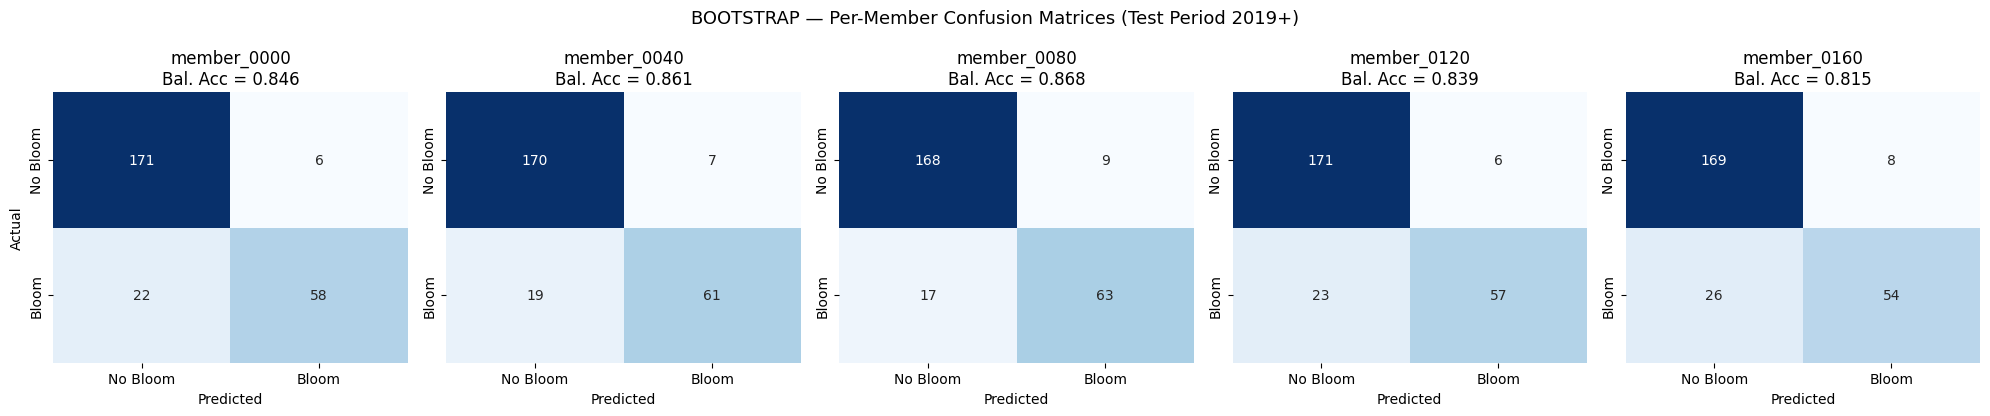

In [6]:
# ── BOOTSTRAP — inference for 5 selected members ────────────────────────
proba_by_method["bootstrap"] = run_inference(features_by_method["bootstrap"], MODEL_PATH, SCALER_PATH)
pred_by_method["bootstrap"]  = (proba_by_method["bootstrap"] >= 0.5).astype(int)

plot_member_cms("bootstrap")


### EnKF

### GLUE

Saved: output\ml\figures\glue_member_cms.png


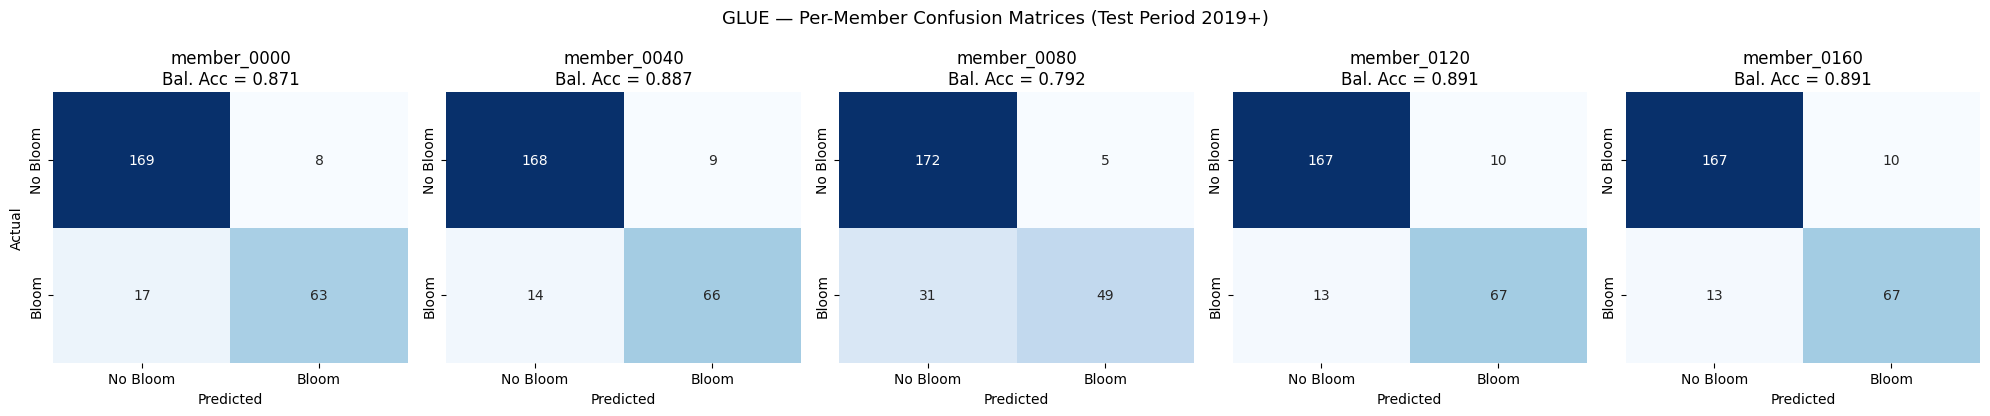

In [7]:
# ── GLUE — inference for 5 selected members ────────────────────────
proba_by_method["glue"] = run_inference(features_by_method["glue"], MODEL_PATH, SCALER_PATH)
pred_by_method["glue"]  = (proba_by_method["glue"] >= 0.5).astype(int)

plot_member_cms("glue")

Saved: output\ml\figures\enkf_member_cms.png


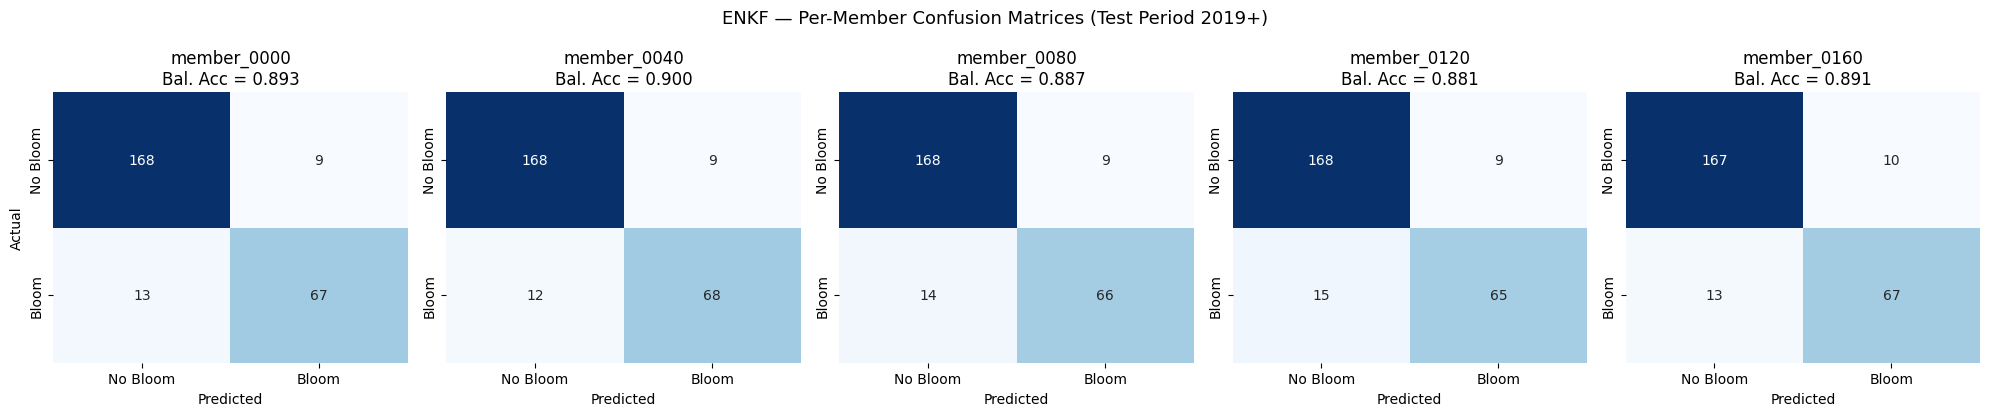

In [8]:
# ── ENKF — inference for 5 selected members ────────────────────────
proba_by_method["enkf"] = run_inference(features_by_method["enkf"], MODEL_PATH, SCALER_PATH)
pred_by_method["enkf"]  = (proba_by_method["enkf"] >= 0.5).astype(int)

plot_member_cms("enkf")


## Final Comparison — Mean [5th, 95th Percentile] Confusion Matrix per Method

For each method, the 5 per-member confusion matrices are averaged element-wise,
and each cell is annotated as `mean` on top with `[p05, p95]` below. The four
ensemble methods occupy the 2×2 block on the left; the baseline CM (single
deterministic run, integer counts) spans the full right column.

Saved: output\ml\figures\all_methods_mean_cm_0_40_80_120_160.png
Method ranking by mean TP: enkf (66.6) > glue (62.4) > bootstrap (58.6)


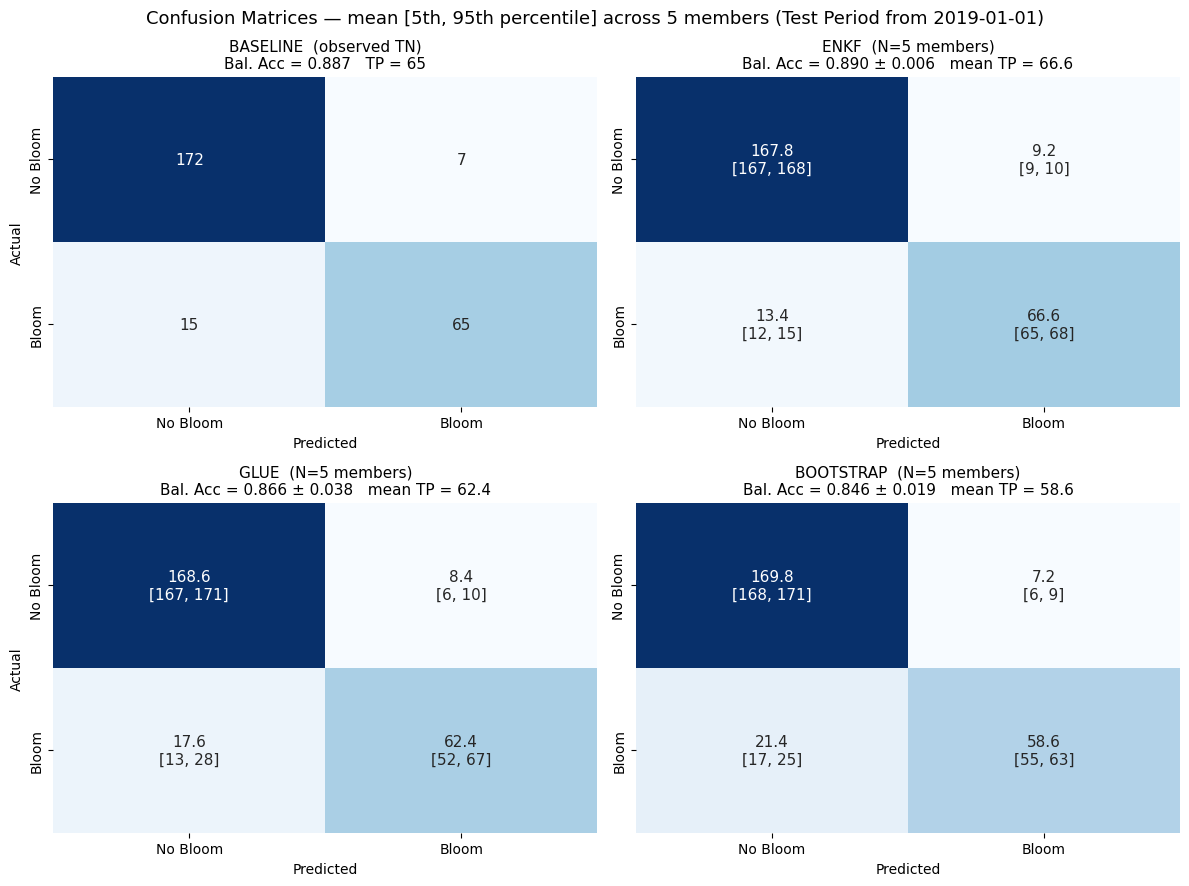

In [9]:
import matplotlib.gridspec as gridspec

# ── Rank ensemble methods by mean True Positive count (descending) ───────────
method_mean_tp = {}
for method in METHODS:
    cms = np.stack([
        confusion_matrix(
            y_test_members,
            pred_by_method[method][j][test_mask_members],
            labels=[0, 1],
        )
        for j in range(len(MEMBER_INDICES))
    ])
    method_mean_tp[method] = cms.mean(axis=0)[1, 1]  # mean TP

ranked_methods = sorted(METHODS, key=lambda m: method_mean_tp[m], reverse=True)

# Layout: 2×2 grid — baseline top-left, then methods by descending mean TP
positions = [(0, 0), (0, 1), (1, 0), (1, 1)]

fig = plt.figure(figsize=(12, 9))
gs = gridspec.GridSpec(2, 2, figure=fig)

# ── Baseline (top-left) ─────────────────────────────────────────────────────
ax_bl = fig.add_subplot(gs[0, 0])
cm_baseline = np.array([[172, 7],
                         [15, 65]])
bal_acc_bl = balanced_accuracy_score(
    [0]*172 + [0]*7 + [1]*15 + [1]*65,
    [0]*172 + [1]*7 + [0]*15 + [1]*65,
)
annot_bl = np.array([[str(172), str(7)],
                      [str(15),  str(65)]])
sns.heatmap(cm_baseline, annot=annot_bl, fmt="", cmap="Blues", ax=ax_bl, cbar=False,
            xticklabels=["No Bloom", "Bloom"],
            yticklabels=["No Bloom", "Bloom"],
            annot_kws={"size": 11})
ax_bl.set_xlabel("Predicted")
ax_bl.set_ylabel("Actual")
ax_bl.set_title(
    f"BASELINE  (observed TN)\n"
    f"Bal. Acc = {bal_acc_bl:.3f}   TP = {65}",
    fontsize=11,
)

# ── Ensemble methods (remaining 3 slots, ranked by mean TP) ─────────────────
for method, (r, c) in zip(ranked_methods, positions[1:]):
    ax = fig.add_subplot(gs[r, c])

    cms = np.stack([
        confusion_matrix(
            y_test_members,
            pred_by_method[method][j][test_mask_members],
            labels=[0, 1],
        )
        for j in range(len(MEMBER_INDICES))
    ])
    cm_mean = cms.mean(axis=0)
    cm_p05  = np.percentile(cms, 5,  axis=0)
    cm_p95  = np.percentile(cms, 95, axis=0)

    annot = np.empty_like(cm_mean, dtype=object)
    for i in range(2):
        for k in range(2):
            annot[i, k] = f"{cm_mean[i, k]:.1f}\n[{cm_p05[i, k]:.0f}, {cm_p95[i, k]:.0f}]"

    sns.heatmap(cm_mean, annot=annot, fmt="", cmap="Blues", ax=ax, cbar=False,
                xticklabels=["No Bloom", "Bloom"],
                yticklabels=["No Bloom", "Bloom"],
                annot_kws={"size": 11})

    bal_accs = [
        balanced_accuracy_score(y_test_members,
                                pred_by_method[method][j][test_mask_members])
        for j in range(len(MEMBER_INDICES))
    ]
    ax.set_xlabel("Predicted")
    ax.set_ylabel("Actual" if c == 0 else "")
    ax.set_title(
        f"{method.upper()}  (N={len(MEMBER_INDICES)} members)\n"
        f"Bal. Acc = {np.mean(bal_accs):.3f} ± {np.std(bal_accs):.3f}   "
        f"mean TP = {cm_mean[1, 1]:.1f}",
        fontsize=11,
    )

fig.suptitle(
    f"Confusion Matrices — mean [5th, 95th percentile] across {len(MEMBER_INDICES)} members "
    f"(Test Period from {TEST_CUTOFF})",
    fontsize=13,
)
plt.tight_layout()

if SAVE_OUTPUTS:
    fname = FIGURES_DIR / f"all_methods_mean_cm_{'_'.join(str(i) for i in MEMBER_INDICES)}.png"
    plt.savefig(fname, dpi=150, bbox_inches="tight")
    print(f"Saved: {fname}")

print(f"Method ranking by mean TP: {' > '.join(f'{m} ({method_mean_tp[m]:.1f})' for m in ranked_methods)}")
plt.show()

## Precision-Recall Curves — All Methods

One line per (method, member) combination, colored by method. Baseline in black.

Saved: output\ml\figures\all_methods_members_0_40_80_120_160_pr.png


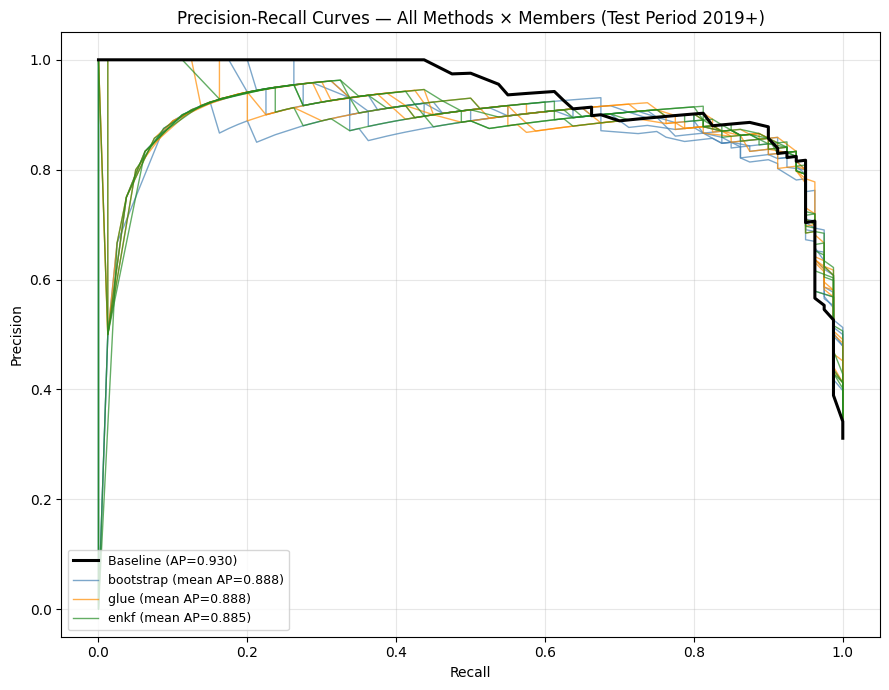

In [10]:
fig, ax = plt.subplots(figsize=(9, 7))

# Baseline
prec_bl, rec_bl, _ = precision_recall_curve(y_test_baseline, baseline_proba[test_mask_baseline])
ap_bl = average_precision_score(y_test_baseline, baseline_proba[test_mask_baseline])
ax.plot(rec_bl, prec_bl, color="black", linewidth=2.2,
        label=f"Baseline (AP={ap_bl:.3f})", zorder=10)

for method in METHODS:
    color = METHOD_COLORS[method]
    proba_test = proba_by_method[method][:, test_mask_members]
    aps = []
    for j, col in enumerate(selected_cols):
        prec, rec, _ = precision_recall_curve(y_test_members, proba_test[j])
        ap = average_precision_score(y_test_members, proba_test[j])
        aps.append(ap)
        ax.plot(rec, prec, color=color, linewidth=1.0, alpha=0.7,
                label=f"{method} (mean AP={np.mean(aps):.3f})" if j == len(selected_cols) - 1 else None)

ax.set_xlabel("Recall")
ax.set_ylabel("Precision")
ax.set_title("Precision-Recall Curves — All Methods × Members (Test Period 2019+)")
ax.grid(True, alpha=0.3)
ax.legend(fontsize=9, loc="lower left")
plt.tight_layout()

if SAVE_OUTPUTS:
    fname = FIGURES_DIR / f"all_methods_members_{'_'.join(str(i) for i in MEMBER_INDICES)}_pr.png"
    plt.savefig(fname, dpi=150, bbox_inches="tight")
    print(f"Saved: {fname}")

plt.show()


## Bloom Probability Traces — Method Means vs Baseline

Saved: output\ml\figures\all_methods_members_0_40_80_120_160_traces_full.png


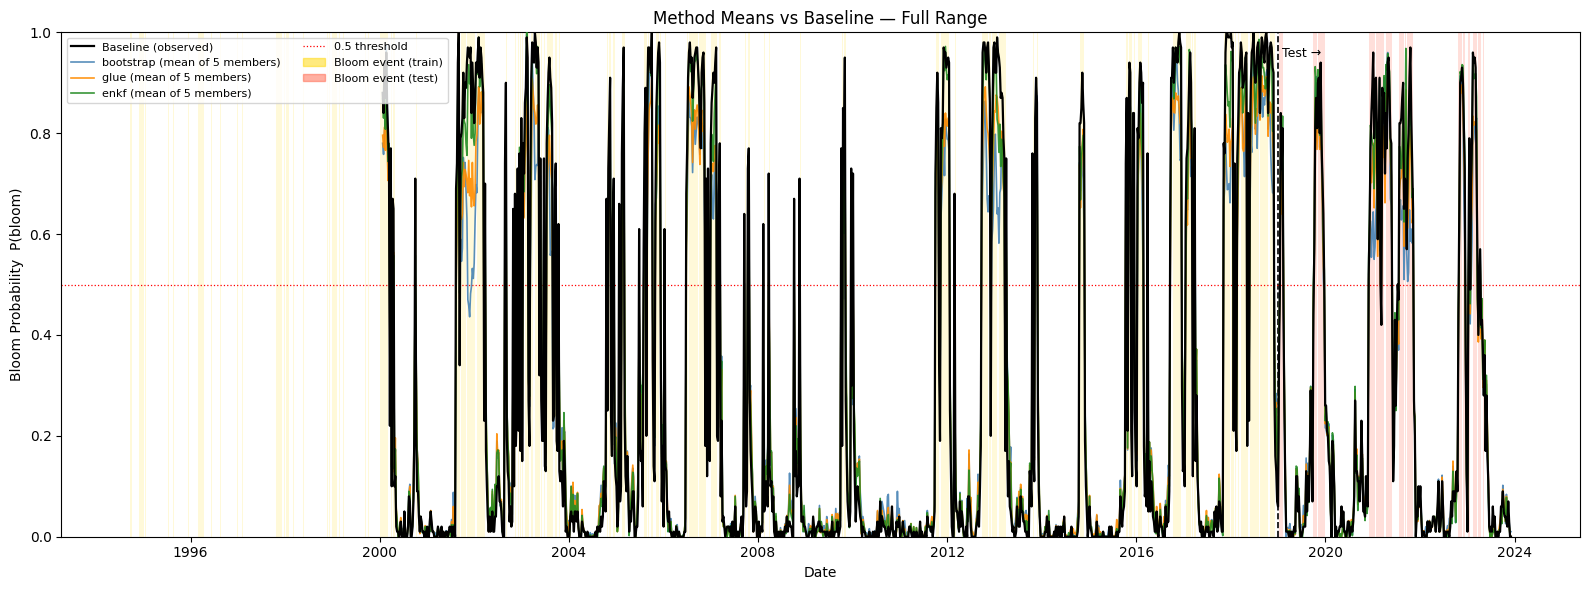

In [11]:
# Bloom event dates (from obs)
obs_bloom   = pd.read_csv(OBS_CSV, parse_dates=["time"], index_col="time")
bloom_dates = obs_bloom.index[obs_bloom["kb"] >= 100_000]
bloom_train = bloom_dates[bloom_dates <  TEST_CUTOFF]
bloom_test  = bloom_dates[bloom_dates >= TEST_CUTOFF]
half_week   = pd.Timedelta(days=3)

fig, ax = plt.subplots(figsize=(16, 6))

for bd in bloom_train:
    ax.axvspan(bd - half_week, bd + half_week, color="gold",   alpha=0.15, linewidth=0)
for bd in bloom_test:
    ax.axvspan(bd - half_week, bd + half_week, color="tomato", alpha=0.20, linewidth=0)

ax.axvline(pd.Timestamp(TEST_CUTOFF), color="black", linestyle="--", linewidth=1.2)
ax.text(pd.Timestamp(TEST_CUTOFF), 0.97, " Test →",
        transform=ax.get_xaxis_transform(), fontsize=9, color="black", va="top")

ax.plot(baseline_dates, baseline_proba, color="black", linewidth=1.6,
        label="Baseline (observed)", zorder=5)

for method in METHODS:
    mean_trace = proba_by_method[method].mean(axis=0)
    ax.plot(aligned_index, mean_trace,
            color=METHOD_COLORS[method], linewidth=1.2, alpha=0.9,
            label=f"{method} (mean of {len(MEMBER_INDICES)} members)", zorder=4)

ax.axhline(0.5, color="red", linestyle=":", linewidth=0.9, label="0.5 threshold")

train_patch = mpatches.Patch(color="gold",   alpha=0.5, label="Bloom event (train)")
test_patch  = mpatches.Patch(color="tomato", alpha=0.5, label="Bloom event (test)")
handles, labels = ax.get_legend_handles_labels()
ax.legend(handles=handles + [train_patch, test_patch], loc="upper left", fontsize=8, ncol=2)

ax.set_ylim(0, 1)
ax.set_ylabel("Bloom Probability  P(bloom)")
ax.set_xlabel("Date")
ax.set_title("Method Means vs Baseline — Full Range", fontsize=12)
plt.tight_layout()

if SAVE_OUTPUTS:
    fname = FIGURES_DIR / f"all_methods_members_{'_'.join(str(i) for i in MEMBER_INDICES)}_traces_full.png"
    plt.savefig(fname, dpi=150, bbox_inches="tight")
    print(f"Saved: {fname}")

plt.show()


## Test Period Zoom (2019+) — Method Means vs Baseline

Saved: output\ml\figures\all_methods_members_0_40_80_120_160_traces_test.png


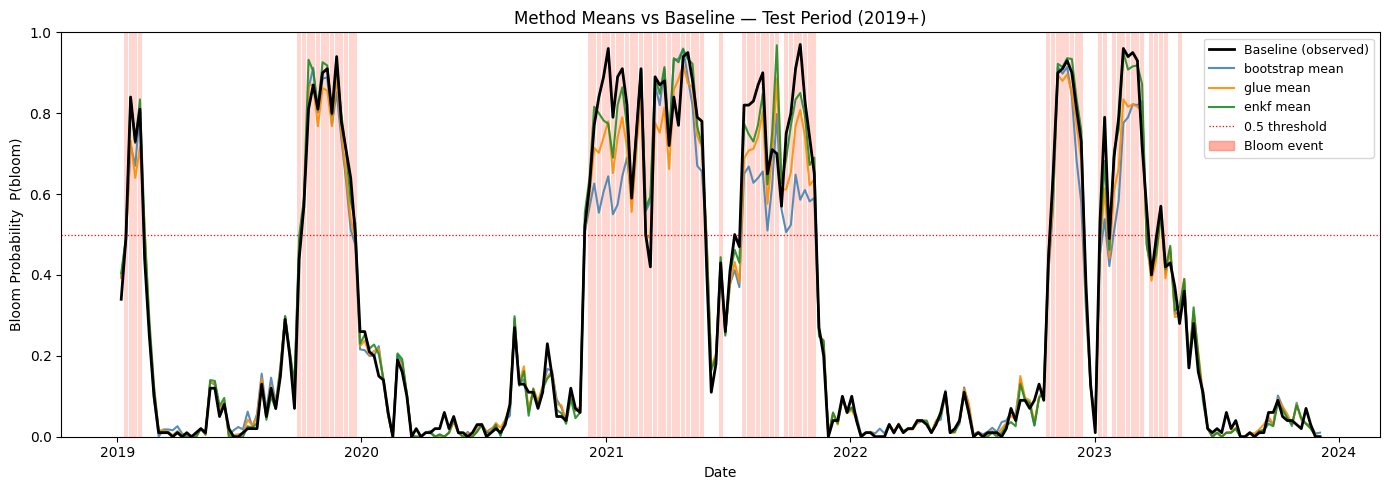

In [12]:
fig, ax = plt.subplots(figsize=(14, 5))

for bd in bloom_test:
    ax.axvspan(bd - half_week, bd + half_week, color="tomato", alpha=0.25, linewidth=0)

ax.plot(baseline_dates[test_mask_baseline], baseline_proba[test_mask_baseline],
        color="black", linewidth=2.0, label="Baseline (observed)", zorder=5)

for method in METHODS:
    mean_trace = proba_by_method[method].mean(axis=0)
    ax.plot(aligned_index[test_mask_members], mean_trace[test_mask_members],
            color=METHOD_COLORS[method], linewidth=1.5, alpha=0.9,
            label=f"{method} mean", zorder=4)

ax.axhline(0.5, color="red", linestyle=":", linewidth=0.9, label="0.5 threshold")

test_patch = mpatches.Patch(color="tomato", alpha=0.5, label="Bloom event")
handles, labels = ax.get_legend_handles_labels()
ax.legend(handles=handles + [test_patch], loc="upper right", fontsize=9)

ax.set_ylim(0, 1)
ax.set_ylabel("Bloom Probability  P(bloom)")
ax.set_xlabel("Date")
ax.set_title("Method Means vs Baseline — Test Period (2019+)", fontsize=12)
plt.tight_layout()

if SAVE_OUTPUTS:
    fname = FIGURES_DIR / f"all_methods_members_{'_'.join(str(i) for i in MEMBER_INDICES)}_traces_test.png"
    plt.savefig(fname, dpi=150, bbox_inches="tight")
    print(f"Saved: {fname}")

plt.show()


## Optional — Export Probability CSV

In [13]:
if SAVE_OUTPUTS:
    series_dict = {
        "baseline": pd.Series(baseline_proba, index=baseline_dates, name="baseline")
    }
    for method in METHODS:
        for j, col in enumerate(selected_cols):
            series_dict[f"{method}_{col}"] = pd.Series(
                proba_by_method[method][j], index=aligned_index,
                name=f"{method}_{col}",
            )
    proba_df = pd.DataFrame(series_dict)
    proba_df.index.name = "date"

    proba_csv = OUTPUT_DIR / f"all_methods_proba_{'_'.join(str(i) for i in MEMBER_INDICES)}.csv"
    proba_df.to_csv(proba_csv)
    print(f"Saved: {proba_csv}  shape={proba_df.shape}")


Saved: output\ml\all_methods_proba_0_40_80_120_160.csv  shape=(1246, 16)


Saved: output\ml\tn_ensemble_vs_baseline_comparison.csv  shape=(3738, 5)


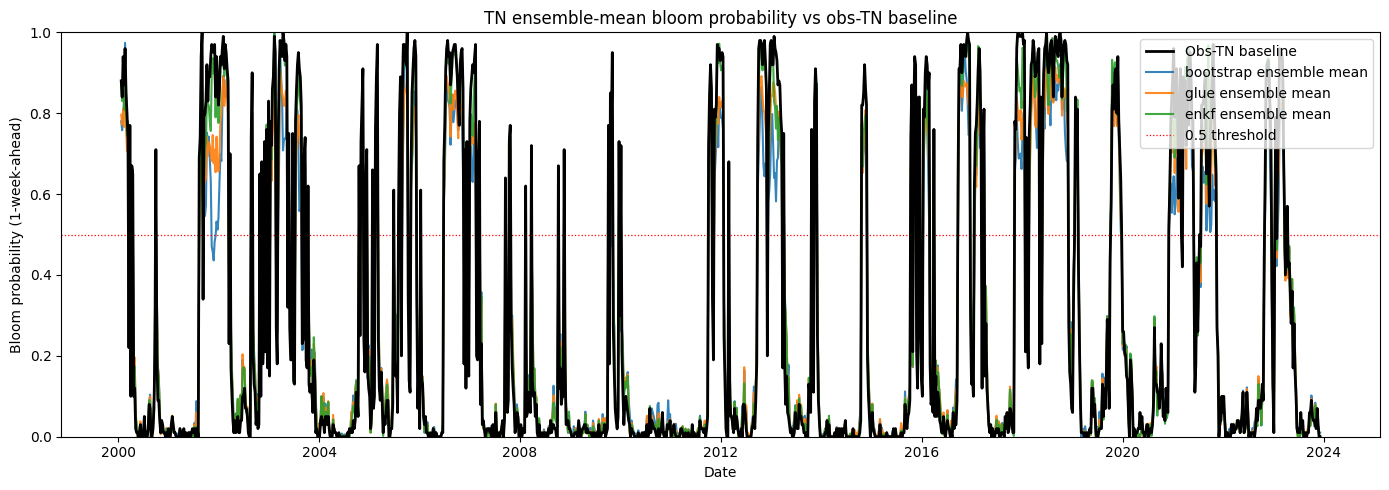

Saved: output\ml\tn_ensemble_vs_baseline_trace.png


In [14]:
# ── Per-method delta-vs-baseline comparison (D-14, D-15) ─────────────────────
rows = []
for method in METHODS:
    ensemble_mean = proba_by_method[method].mean(axis=0)   # (T,)
    # baseline and ensemble share aligned_index, so element-wise subtraction is safe
    delta = ensemble_mean - proba_baseline
    rows.append(pd.DataFrame({
        "method": method,
        "date": aligned_index,
        "ensemble_mean": ensemble_mean,
        "baseline": proba_baseline,
        "delta": delta,
    }))
comparison_df = pd.concat(rows, ignore_index=True)
comparison_csv = OUTPUT_DIR / "tn_ensemble_vs_baseline_comparison.csv"
comparison_df.to_csv(comparison_csv, index=False)
print(f"Saved: {comparison_csv}  shape={comparison_df.shape}")

# Combined probability-trace plot: baseline (black) + ensemble mean per method
fig, ax = plt.subplots(figsize=(14, 5))
ax.plot(aligned_index, proba_baseline, color="black", linewidth=2.0,
        label="Obs-TN baseline", zorder=5)
for method in METHODS:
    ax.plot(aligned_index, proba_by_method[method].mean(axis=0),
            linewidth=1.5, alpha=0.9, label=f"{method} ensemble mean")
ax.axhline(0.5, color="red", linestyle=":", linewidth=0.9, label="0.5 threshold")
ax.set_ylim(0, 1)
ax.set_ylabel("Bloom probability (1-week-ahead)")
ax.set_xlabel("Date")
ax.set_title("TN ensemble-mean bloom probability vs obs-TN baseline")
ax.legend(loc="upper right")
plt.tight_layout()
plot_path = OUTPUT_DIR / "tn_ensemble_vs_baseline_trace.png"
plt.savefig(plot_path, dpi=120)
plt.show()
print(f"Saved: {plot_path}")
